## Disease Prediction (Diabetes Prediction)

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [160]:
df = pd.read_csv("diabetes.csv")

print(df.head())
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null  

In [161]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Display the correlation matrix

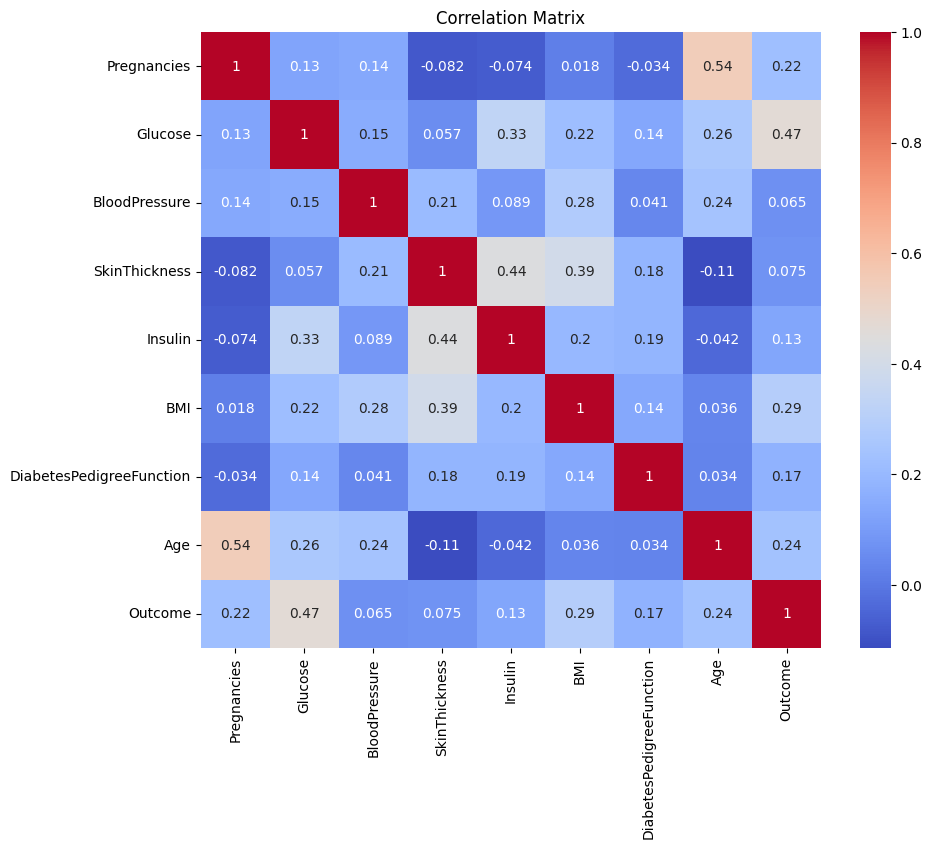

In [162]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

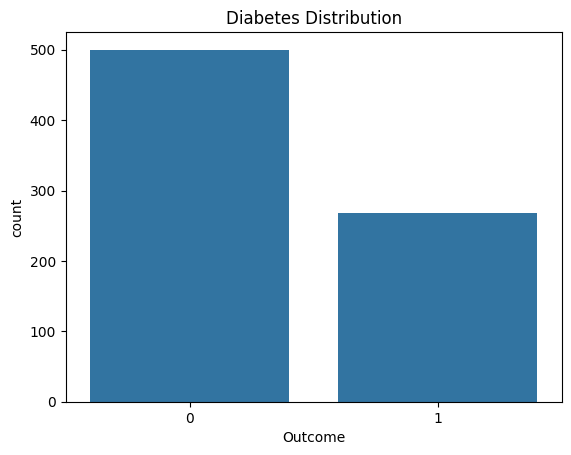

In [163]:
# Visualize the distribution of the target variable
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

In [164]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [165]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [166]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [167]:
svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [168]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [169]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.714286   0.608696  0.518519  0.560000
1                  SVM  0.753247   0.660000  0.611111  0.634615
2        Random Forest  0.746753   0.653061  0.592593  0.621359


In [170]:
best_model = svm
print(f"Best Model: {best_model.__class__.__name__}")

Best Model: SVC


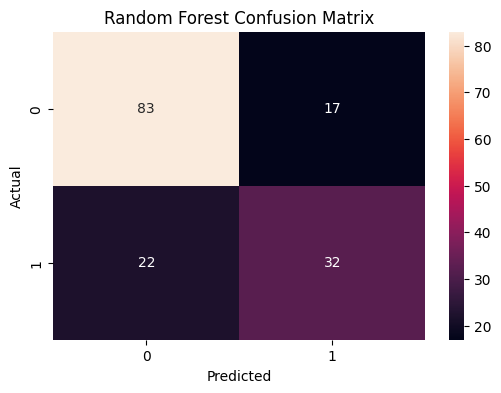

In [171]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [172]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



In [173]:
import pickle

with open("diabetes_prediction_model.pkl", "wb") as file:
    pickle.dump(rf, file)

In [174]:
plt.savefig("screenshots/confusion_matrix.png")
plt.savefig("screenshots/correlation_matrix.png")


<Figure size 640x480 with 0 Axes>